# YuvaIntern: Experimental Design and Evaluation

This notebook performs supplementary validation experiments
for the carbon-emission machine learning project.

It contains two evaluation procedures:

1. Five-fold country-grouped cross-validation for
   Linear Regression, Random Forest and Gradient Boosting.

2. Expanding-window rolling-origin evaluation for the
   lag-based Gradient Boosting forecasting model.

The experiments use the existing processed modeling dataset
and established model configurations. The original notebooks
and their results are kept unchanged.

All additional evaluation files are saved separately under
outputs/yuvaintern_evaluation/.

Country-grouped cross-validation evaluates generalization
to countries excluded from each training fold [1].

Rolling-origin evaluation assesses predictions at successive
time-based origins using earlier observations for training [2].

The forecasting evaluation uses observed same-year
socioeconomic and energy-related predictors. It therefore
represents conditional one-year-ahead prediction, rather
than a fully prospective forecast with unknown future inputs.

In [1]:
# ============================================================
# CELL 2 - Imports and Configuration
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Dataset and output paths
DATA_PATH = Path("../data/processed/modeling_data.csv")
OUTPUT_DIR = Path("../outputs/yuvaintern_evaluation")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility and evaluation settings
RANDOM_STATE = 42
N_SPLITS = 5

print("=" * 60)
print("YUVINTERN EXPERIMENTAL EVALUATION")
print("=" * 60)

print("Dataset path:", DATA_PATH)
print("Output directory:", OUTPUT_DIR)
print("Cross-validation folds:", N_SPLITS)

YUVINTERN EXPERIMENTAL EVALUATION
Dataset path: ..\data\processed\modeling_data.csv
Output directory: ..\outputs\yuvaintern_evaluation
Cross-validation folds: 5


In [2]:
# ============================================================
# CELL 3 - Load and Validate Data
# ============================================================

df = pd.read_csv(DATA_PATH)

target = "co2"

features = [
    "year",
    "population_co2",
    "gdp_co2",
    "primary_energy_consumption_energy",
    "fossil_share_energy",
    "renewables_share_energy",
    "renewables_electricity",
    "renewables_share_elec",
    "solar_share_energy",
    "wind_share_energy",
    "hydro_share_energy",
    "gdp_per_capita",
    "energy_per_capita"
]

required_columns = ["country", target] + features

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

if df[required_columns].isna().any().any():
    raise ValueError(
        "Missing values found in required columns. "
        "Review the processed dataset before evaluation."
    )

if df["country"].nunique() < N_SPLITS:
    raise ValueError(
        "The number of distinct countries is smaller "
        "than the number of cross-validation folds."
    )

print("=" * 60)
print("DATASET CHECK")
print("=" * 60)

print("Dataset shape:", df.shape)
print("Countries:", df["country"].nunique())
print("Year range:", df["year"].min(), "-", df["year"].max())
print("Predictive features:", len(features))
print("Target:", target)
print("Missing values in required columns: 0")

DATASET CHECK
Dataset shape: (1817, 16)
Countries: 79
Year range: 2000 - 2022
Predictive features: 13
Target: co2
Missing values in required columns: 0


In [3]:
# ============================================================
# CELL 4 - Existing Split and Regression Models
# ============================================================

X = df[features]
y = df[target]

# Reproduce the existing 70/15/15 random split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)

# Country identifiers aligned with training rows
groups_train = df.loc[X_train.index, "country"]

# Verify index alignment
assert X_train.index.equals(y_train.index)
assert X_train.index.equals(groups_train.index)

# Use the established model configurations
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

print("=" * 60)
print("BASELINE SPLIT")
print("=" * 60)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Countries in training:", groups_train.nunique())

print("\nRegression models initialized:")
for name in models:
    print("-", name)

BASELINE SPLIT
Training: (1271, 13)
Validation: (273, 13)
Test: (273, 13)
Countries in training: 79

Regression models initialized:
- Linear Regression
- Random Forest
- Gradient Boosting


In [4]:
# ============================================================
# CELL 5 - Country-Grouped Cross-Validation
# ============================================================

group_cv = GroupKFold(n_splits=N_SPLITS)

cv_fold_rows = []
cv_pooled_rows = []

print("=" * 60)
print("FIVE-FOLD COUNTRY-GROUPED CROSS-VALIDATION")
print("=" * 60)

for model_name, estimator in models.items():

    print(f"\nEvaluating: {model_name}")

    # One out-of-fold prediction slot for each training row
    oof_predictions = np.full(
        shape=len(X_train),
        fill_value=np.nan
    )

    y_train_array = y_train.to_numpy()

    for fold_number, (train_idx, val_idx) in enumerate(
        group_cv.split(
            X_train,
            y_train,
            groups=groups_train
        ),
        start=1
    ):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        train_countries = set(
            groups_train.iloc[train_idx]
        )
        val_countries = set(
            groups_train.iloc[val_idx]
        )

        country_overlap = train_countries.intersection(
            val_countries
        )

        if country_overlap:
            raise ValueError(
                f"Country leakage detected in fold {fold_number}: "
                f"{country_overlap}"
            )

        # Clone the model so each fold begins untrained
        fold_model = clone(estimator)

        # Fit preprocessing and model only on fold training data
        fold_model.fit(X_fold_train, y_fold_train)

        # Predict the held-out countries
        fold_pred = fold_model.predict(X_fold_val)

        # Store out-of-fold predictions by row position
        oof_predictions[val_idx] = fold_pred

        # Calculate fold metrics
        fold_mae = mean_absolute_error(
            y_fold_val,
            fold_pred
        )

        fold_rmse = np.sqrt(
            mean_squared_error(
                y_fold_val,
                fold_pred
            )
        )

        fold_r2 = r2_score(
            y_fold_val,
            fold_pred
        )

        cv_fold_rows.append({
            "Model": model_name,
            "Fold": fold_number,
            "Training Samples": len(train_idx),
            "Validation Samples": len(val_idx),
            "Training Countries": len(train_countries),
            "Validation Countries": len(val_countries),
            "Country Overlap": len(country_overlap),
            "MAE": fold_mae,
            "RMSE": fold_rmse,
            "R2": fold_r2
        })

        print(
            f"Fold {fold_number}: "
            f"MAE={fold_mae:.4f}, "
            f"RMSE={fold_rmse:.4f}, "
            f"R²={fold_r2:.4f}, "
            f"country overlap={len(country_overlap)}"
        )

    # Every training observation should receive exactly
    # one out-of-fold prediction
    if np.isnan(oof_predictions).any():
        raise ValueError(
            f"Missing out-of-fold predictions for {model_name}"
        )

    # Pooled out-of-fold metrics across the training partition
    cv_pooled_rows.append({
        "Model": model_name,
        "OOF_MAE": mean_absolute_error(
            y_train_array,
            oof_predictions
        ),
        "OOF_RMSE": np.sqrt(
            mean_squared_error(
                y_train_array,
                oof_predictions
            )
        ),
        "OOF_R2": r2_score(
            y_train_array,
            oof_predictions
        )
    })

print("\nCross-validation completed.")

FIVE-FOLD COUNTRY-GROUPED CROSS-VALIDATION

Evaluating: Linear Regression
Fold 1: MAE=133.7606, RMSE=289.6294, R²=0.9418, country overlap=0
Fold 2: MAE=61.9131, RMSE=92.6625, R²=0.7366, country overlap=0
Fold 3: MAE=160.5225, RMSE=533.5865, R²=0.9330, country overlap=0
Fold 4: MAE=57.2505, RMSE=77.1047, R²=0.9313, country overlap=0
Fold 5: MAE=64.8832, RMSE=125.3011, R²=0.6357, country overlap=0

Evaluating: Random Forest
Fold 1: MAE=181.4494, RMSE=641.4965, R²=0.7144, country overlap=0
Fold 2: MAE=29.5106, RMSE=42.9012, R²=0.9435, country overlap=0
Fold 3: MAE=306.4186, RMSE=970.5859, R²=0.7783, country overlap=0
Fold 4: MAE=74.2645, RMSE=157.7592, R²=0.7126, country overlap=0
Fold 5: MAE=95.1849, RMSE=198.8601, R²=0.0823, country overlap=0

Evaluating: Gradient Boosting
Fold 1: MAE=203.3203, RMSE=756.1348, R²=0.6032, country overlap=0
Fold 2: MAE=32.9146, RMSE=47.4718, R²=0.9309, country overlap=0
Fold 3: MAE=334.8653, RMSE=1041.1426, R²=0.7449, country overlap=0
Fold 4: MAE=57.6118,

In [5]:
# ============================================================
# CELL 6 - Cross-Validation Summary and Export
# ============================================================

cv_fold_results = pd.DataFrame(cv_fold_rows)
cv_pooled_results = pd.DataFrame(cv_pooled_rows)

cv_summary = (
    cv_fold_results
    .groupby("Model")
    .agg(
        Fold_MAE_Mean=("MAE", "mean"),
        Fold_MAE_Std=("MAE", "std"),
        Fold_RMSE_Mean=("RMSE", "mean"),
        Fold_RMSE_Std=("RMSE", "std"),
        Fold_R2_Mean=("R2", "mean"),
        Fold_R2_Std=("R2", "std")
    )
    .reset_index()
    .merge(
        cv_pooled_results,
        on="Model",
        how="left"
    )
    .sort_values("Fold_RMSE_Mean")
)

print("=" * 60)
print("COUNTRY-GROUPED CROSS-VALIDATION RESULTS")
print("=" * 60)

display(cv_fold_results.round(4))

print("\nSUMMARY ACROSS FIVE FOLDS")
display(cv_summary.round(4))

# Export detailed and summary results
cv_fold_results.to_csv(
    OUTPUT_DIR / "grouped_cv_fold_results.csv",
    index=False
)

cv_pooled_results.to_csv(
    OUTPUT_DIR / "grouped_cv_pooled_results.csv",
    index=False
)

cv_summary.to_csv(
    OUTPUT_DIR / "grouped_cv_summary.csv",
    index=False
)

print("\nSaved:")
print(OUTPUT_DIR / "grouped_cv_fold_results.csv")
print(OUTPUT_DIR / "grouped_cv_pooled_results.csv")
print(OUTPUT_DIR / "grouped_cv_summary.csv")

COUNTRY-GROUPED CROSS-VALIDATION RESULTS


,Model,Fold,Training Samples,Validation Samples,Training Countries,Validation Countries,Country Overlap,MAE,RMSE,R2
0,Linear Regression,1,1014,257,63,16,0,133.7606,289.6294,0.9418
1,Linear Regression,2,1014,257,63,16,0,61.9131,92.6625,0.7366
2,Linear Regression,3,1014,257,63,16,0,160.5225,533.5865,0.9330
3,Linear Regression,4,1016,255,63,16,0,57.2505,77.1047,0.9313
4,Linear Regression,5,1026,245,64,15,0,64.8832,125.3011,0.6357
5,Random Forest,1,1014,257,63,16,0,181.4494,641.4965,0.7144
6,Random Forest,2,1014,257,63,16,0,29.5106,42.9012,0.9435
7,Random Forest,3,1014,257,63,16,0,306.4186,970.5859,0.7783
8,Random Forest,4,1016,255,63,16,0,74.2645,157.7592,0.7126
9,Random Forest,5,1026,245,64,15,0,95.1849,198.8601,0.0823



SUMMARY ACROSS FIVE FOLDS


,Model,Fold_MAE_Mean,Fold_MAE_Std,Fold_RMSE_Mean,Fold_RMSE_Std,Fold_R2_Mean,Fold_R2_Std,OOF_MAE,OOF_RMSE,OOF_R2
1,Linear Regression,95.6660,48.0108,223.6568,192.8209,0.8357,0.1412,96.0170,283.7029,0.9345
2,Random Forest,137.3656,109.4486,402.3206,390.6787,0.6462,0.3290,137.8631,535.4261,0.7665
0,Gradient Boosting,138.3619,128.5862,411.5741,456.5460,0.7752,0.1305,139.1996,582.8486,0.7233



Saved:
..\outputs\yuvaintern_evaluation\grouped_cv_fold_results.csv
..\outputs\yuvaintern_evaluation\grouped_cv_pooled_results.csv
..\outputs\yuvaintern_evaluation\grouped_cv_summary.csv


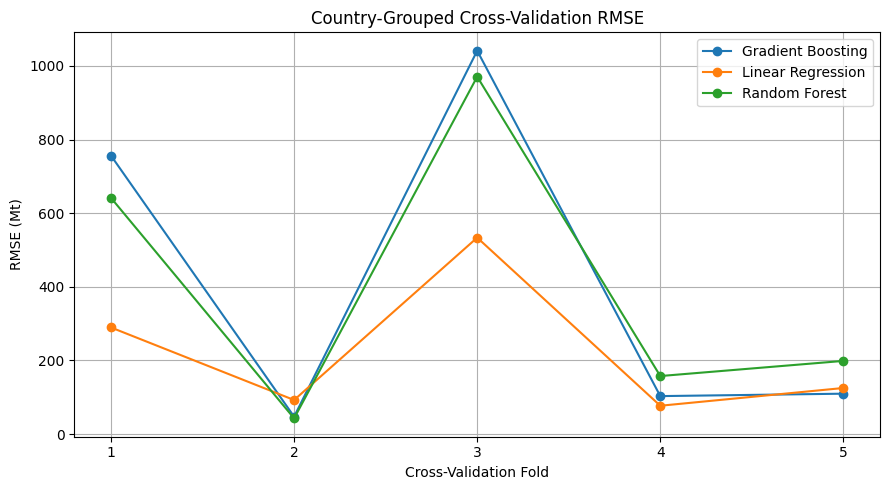

In [6]:
# ============================================================
# CELL 7 - Cross-Validation RMSE Plot
# ============================================================

plt.figure(figsize=(9, 5))

for model_name, group in cv_fold_results.groupby("Model"):
    plt.plot(
        group["Fold"],
        group["RMSE"],
        marker="o",
        label=model_name
    )

plt.xlabel("Cross-Validation Fold")
plt.ylabel("RMSE (Mt)")
plt.title("Country-Grouped Cross-Validation RMSE")
plt.xticks(range(1, N_SPLITS + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "grouped_cv_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# ============================================================
# CELL 8 - Prepare Time-Series Data
# ============================================================

print("=" * 60)
print("ROLLING-ORIGIN DATA PREPARATION")
print("=" * 60)

ts_df = pd.read_csv(DATA_PATH)

# Sort observations before constructing country-specific lags
ts_df = ts_df.sort_values(
    ["country", "year"]
).reset_index(drop=True)

# Verify consecutive annual observations within each country
year_differences = (
    ts_df.groupby("country")["year"]
    .diff()
    .dropna()
)

if not year_differences.eq(1).all():
    raise ValueError(
        "Non-consecutive years detected within at least one "
        "country. Review the panel before creating calendar-year lags."
    )

# Construct country-specific CO2 lag features
for lag in [1, 2, 3]:
    ts_df[f"co2_lag_{lag}"] = (
        ts_df.groupby("country")["co2"].shift(lag)
    )

# Use the same predictors as Notebook 6, plus three lag features
ts_features = features + [
    "co2_lag_1",
    "co2_lag_2",
    "co2_lag_3"
]

# Match the existing forecasting notebook's complete-case approach
ts_df = ts_df.dropna().copy()

print("Rows after lag creation:", len(ts_df))
print("Countries:", ts_df["country"].nunique())
print(
    "Available year range:",
    ts_df["year"].min(),
    "-",
    ts_df["year"].max()
)
print("Forecasting features:", len(ts_features))

ROLLING-ORIGIN DATA PREPARATION
Rows after lag creation: 1580
Countries: 79
Available year range: 2003 - 2022
Forecasting features: 16


In [8]:
# ============================================================
# CELL 9 - Expanding-Window Rolling-Origin Evaluation
# ============================================================

print("=" * 60)
print("EXPANDING-WINDOW ROLLING-ORIGIN EVALUATION")
print("=" * 60)

# These validation years are within the original
# forecasting model's training period, which ends in 2016.
rolling_validation_years = [2012, 2013, 2014, 2015, 2016]

available_years = set(ts_df["year"].unique())

missing_years = [
    year for year in rolling_validation_years
    if year not in available_years
]

if missing_years:
    raise ValueError(
        f"Required validation years are unavailable: {missing_years}"
    )

rolling_fold_rows = []
rolling_prediction_frames = []

for validation_year in rolling_validation_years:

    # Expanding training window:
    # all available data strictly before the validation year
    train_fold = ts_df[
        ts_df["year"] < validation_year
    ].copy()

    # One-year validation window
    val_fold = ts_df[
        ts_df["year"] == validation_year
    ].copy()

    if train_fold.empty or val_fold.empty:
        raise ValueError(
            f"Empty training or validation data for {validation_year}"
        )

    # Confirm that the training data do not extend into
    # the validation year or beyond
    assert train_fold["year"].max() < validation_year
    assert val_fold["year"].nunique() == 1

    X_fold_train = train_fold[ts_features]
    y_fold_train = train_fold["co2"]

    X_fold_val = val_fold[ts_features]
    y_fold_val = val_fold["co2"]

    # Match the existing Notebook 6 forecasting configuration
    fold_model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    # Train only on earlier years
    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    # One-year-ahead conditional prediction:
    # validation-year non-lag predictors are observed inputs
    fold_pred = fold_model.predict(X_fold_val)

    # Calculate metrics for this validation year
    fold_mae = mean_absolute_error(
        y_fold_val,
        fold_pred
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_fold_val,
            fold_pred
        )
    )

    fold_r2 = r2_score(
        y_fold_val,
        fold_pred
    )

    rolling_fold_rows.append({
        "Validation Year": validation_year,
        "Training Start": train_fold["year"].min(),
        "Training End": train_fold["year"].max(),
        "Training Samples": len(train_fold),
        "Validation Samples": len(val_fold),
        "Training Countries": train_fold["country"].nunique(),
        "Validation Countries": val_fold["country"].nunique(),
        "MAE": fold_mae,
        "RMSE": fold_rmse,
        "R2": fold_r2
    })

    # Store observation-level predictions for further analysis
    fold_predictions = val_fold[
        ["country", "year", "co2"]
    ].copy()

    fold_predictions["predicted_co2"] = fold_pred

    fold_predictions["residual"] = (
        fold_predictions["co2"]
        - fold_predictions["predicted_co2"]
    )

    fold_predictions["absolute_error"] = (
        fold_predictions["residual"].abs()
    )

    rolling_prediction_frames.append(fold_predictions)

    print(
        f"Validation year: {validation_year} | "
        f"Training through: {train_fold['year'].max()} | "
        f"MAE: {fold_mae:.4f} | "
        f"RMSE: {fold_rmse:.4f} | "
        f"R²: {fold_r2:.4f}"
    )

# Combine fold-level and observation-level results
rolling_fold_results = pd.DataFrame(rolling_fold_rows)

rolling_predictions = pd.concat(
    rolling_prediction_frames,
    ignore_index=True
)

print("\nROLLING-ORIGIN FOLD RESULTS")
display(rolling_fold_results.round(4))

EXPANDING-WINDOW ROLLING-ORIGIN EVALUATION
Validation year: 2012 | Training through: 2011 | MAE: 15.5967 | RMSE: 55.2325 | R²: 0.9980
Validation year: 2013 | Training through: 2012 | MAE: 12.1644 | RMSE: 28.5620 | R²: 0.9995
Validation year: 2014 | Training through: 2013 | MAE: 30.5206 | RMSE: 198.1058 | R²: 0.9761
Validation year: 2015 | Training through: 2014 | MAE: 34.2939 | RMSE: 204.9885 | R²: 0.9737
Validation year: 2016 | Training through: 2015 | MAE: 11.7882 | RMSE: 33.6902 | R²: 0.9993

ROLLING-ORIGIN FOLD RESULTS


,Validation Year,Training Start,Training End,Training Samples,Validation Samples,Training Countries,Validation Countries,MAE,RMSE,R2
0,2012,2003,2011,711,79,79,79,15.5967,55.2325,0.9980
1,2013,2003,2012,790,79,79,79,12.1644,28.5620,0.9995
2,2014,2003,2013,869,79,79,79,30.5206,198.1058,0.9761
3,2015,2003,2014,948,79,79,79,34.2939,204.9885,0.9737
4,2016,2003,2015,1027,79,79,79,11.7882,33.6902,0.9993


In [9]:
# ============================================================
# CELL 10 - Rolling-Origin Summary and Export
# ============================================================

print("=" * 60)
print("ROLLING-ORIGIN SUMMARY")
print("=" * 60)

# Mean and standard deviation across validation years
rolling_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Mean Across Folds": [
        rolling_fold_results["MAE"].mean(),
        rolling_fold_results["RMSE"].mean(),
        rolling_fold_results["R2"].mean()
    ],
    "Standard Deviation Across Folds": [
        rolling_fold_results["MAE"].std(),
        rolling_fold_results["RMSE"].std(),
        rolling_fold_results["R2"].std()
    ]
})

# Pooled metrics across all annual validation predictions
pooled_mae = mean_absolute_error(
    rolling_predictions["co2"],
    rolling_predictions["predicted_co2"]
)

pooled_rmse = np.sqrt(
    mean_squared_error(
        rolling_predictions["co2"],
        rolling_predictions["predicted_co2"]
    )
)

pooled_r2 = r2_score(
    rolling_predictions["co2"],
    rolling_predictions["predicted_co2"]
)

pooled_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Pooled Out-of-Fold Result": [
        pooled_mae,
        pooled_rmse,
        pooled_r2
    ]
})

print("Metric variation across validation years:")
display(rolling_summary.round(4))

print("\nPooled observation-level results:")
display(pooled_results.round(4))

# Export all rolling-origin results
rolling_fold_results.to_csv(
    OUTPUT_DIR / "rolling_origin_fold_results.csv",
    index=False
)

rolling_predictions.to_csv(
    OUTPUT_DIR / "rolling_origin_predictions.csv",
    index=False
)

rolling_summary.to_csv(
    OUTPUT_DIR / "rolling_origin_summary.csv",
    index=False
)

pooled_results.to_csv(
    OUTPUT_DIR / "rolling_origin_pooled_results.csv",
    index=False
)

print("\nSaved rolling-origin files:")
for filename in [
    "rolling_origin_fold_results.csv",
    "rolling_origin_predictions.csv",
    "rolling_origin_summary.csv",
    "rolling_origin_pooled_results.csv"
]:
    print(OUTPUT_DIR / filename)

ROLLING-ORIGIN SUMMARY
Metric variation across validation years:


,Metric,Mean Across Folds,Standard Deviation Across Folds
0,MAE,20.8728,10.7169
1,RMSE,104.1158,89.5365
2,R2,0.9893,0.0132



Pooled observation-level results:


,Metric,Pooled Out-of-Fold Result
0,MAE,20.8728
1,RMSE,131.3527
2,R2,0.9892



Saved rolling-origin files:
..\outputs\yuvaintern_evaluation\rolling_origin_fold_results.csv
..\outputs\yuvaintern_evaluation\rolling_origin_predictions.csv
..\outputs\yuvaintern_evaluation\rolling_origin_summary.csv
..\outputs\yuvaintern_evaluation\rolling_origin_pooled_results.csv


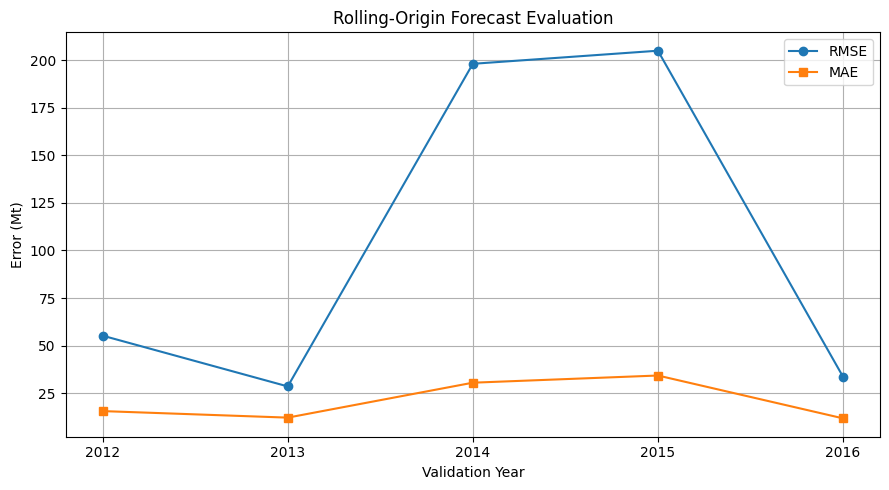

In [10]:
# ============================================================
# CELL 11 - Rolling-Origin Performance Visualization
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    rolling_fold_results["Validation Year"],
    rolling_fold_results["RMSE"],
    marker="o",
    label="RMSE"
)

plt.plot(
    rolling_fold_results["Validation Year"],
    rolling_fold_results["MAE"],
    marker="s",
    label="MAE"
)

plt.xlabel("Validation Year")
plt.ylabel("Error (Mt)")
plt.title("Rolling-Origin Forecast Evaluation")
plt.xticks(rolling_validation_years)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "rolling_origin_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# ============================================================
# CELL 12 - Investigate High-Error Forecast Years
# ============================================================

print("=" * 60)
print("ROLLING-ORIGIN ERROR INVESTIGATION")
print("=" * 60)

for year in [2014, 2015]:

    year_errors = (
        rolling_predictions[
            rolling_predictions["year"] == year
        ]
        .assign(
            absolute_error=lambda x: x["residual"].abs()
        )
        .sort_values(
            "absolute_error",
            ascending=False
        )
    )

    print(f"\nLargest errors in {year}:")
    display(
        year_errors[
            [
                "country",
                "year",
                "co2",
                "predicted_co2",
                "residual",
                "absolute_error"
            ]
        ].head(10).round(3)
    )

ROLLING-ORIGIN ERROR INVESTIGATION

Largest errors in 2014:


,country,year,co2,predicted_co2,residual,absolute_error
186,India,2014,2148.052,3903.882,-1755.830,1755.830
193,Japan,2014,1260.272,1330.152,-69.880,69.880
230,Ukraine,2014,257.703,301.849,-44.146,44.146
214,Russia,2014,1637.311,1678.059,-40.748,40.748
170,China,2014,9976.027,9938.823,37.204,37.204
194,Kazakhstan,2014,299.137,262.135,37.002,37.002
180,France,2014,327.809,358.439,-30.630,30.630
235,Venezuela,2014,175.992,206.434,-30.442,30.442
232,United Kingdom,2014,438.807,467.889,-29.081,29.081
188,Iran,2014,644.228,623.575,20.653,20.653



Largest errors in 2015:


,country,year,co2,predicted_co2,residual,absolute_error
265,India,2015,2231.817,4039.005,-1807.188,1807.188
312,United States,2015,5368.497,5526.487,-157.990,157.990
249,China,2015,9858.040,9969.853,-111.813,111.813
272,Japan,2015,1219.982,1275.081,-55.099,55.099
245,Brazil,2015,528.174,571.905,-43.731,43.731
266,Indonesia,2015,551.160,507.634,43.526,43.526
294,Saudi Arabia,2015,624.547,584.887,39.660,39.660
315,Vietnam,2015,213.391,176.027,37.365,37.365
309,Ukraine,2015,223.850,260.483,-36.634,36.634
259,France,2015,332.131,305.097,27.034,27.034


In [12]:
# ============================================================
# CELL 13 - India Forecast Error Investigation
# ============================================================

print("=" * 65)
print("INDIA: ROLLING-ORIGIN ERROR INVESTIGATION")
print("=" * 65)

# Merge India observations with its stored predictions
india_check = ts_df[
    ts_df["country"] == "India"
].merge(
    rolling_predictions[
        ["country", "year", "predicted_co2",
         "residual", "absolute_error"]
    ],
    on=["country", "year"],
    how="inner"
).sort_values("year")

# Calculate signed and absolute percentage errors
india_check["percentage_error"] = (
    india_check["residual"]
    / india_check["co2"].replace(0, np.nan)
) * 100

india_check["absolute_percentage_error"] = (
    india_check["percentage_error"].abs()
)

# Display target, predictions, lag values and major
# socioeconomic/energy inputs
diagnostic_columns = [
    "country",
    "year",
    "co2",
    "predicted_co2",
    "residual",
    "absolute_error",
    "percentage_error",
    "co2_lag_1",
    "co2_lag_2",
    "co2_lag_3",
    "population_co2",
    "gdp_co2",
    "primary_energy_consumption_energy",
    "fossil_share_energy",
    "renewables_share_energy",
    "renewables_electricity",
    "gdp_per_capita",
    "energy_per_capita"
]

print("\nIndia's observations and model inputs:")
display(
    india_check[diagnostic_columns]
    .round(3)
)

# Calculate India's share of total squared error
print("\nIndia's contribution to yearly squared error:")

for year in [2012, 2013, 2014, 2015, 2016]:

    year_data = rolling_predictions[
        rolling_predictions["year"] == year
    ]

    india_data = year_data[
        year_data["country"] == "India"
    ]

    if india_data.empty:
        continue

    total_squared_error = (
        year_data["residual"] ** 2
    ).sum()

    india_squared_error = (
        india_data["residual"] ** 2
    ).sum()

    contribution_pct = (
        india_squared_error / total_squared_error * 100
        if total_squared_error > 0
        else np.nan
    )

    print(
        f"{year}: India contributes "
        f"{contribution_pct:.2f}% of total squared error"
    )

INDIA: ROLLING-ORIGIN ERROR INVESTIGATION

India's observations and model inputs:


,country,year,co2,predicted_co2,residual,absolute_error,percentage_error,co2_lag_1,co2_lag_2,co2_lag_3,population_co2,gdp_co2,primary_energy_consumption_energy,fossil_share_energy,renewables_share_energy,renewables_electricity,gdp_per_capita,energy_per_capita
0,India,2012,1926.986,1750.610,176.376,176.376,9.153,1765.695,1678.530,1613.328,1.278675e+09,6.052427e+12,6937.768,92.556,6.208,161.83,4733.361,5425.750
1,India,2013,1995.337,1928.897,66.440,66.440,3.330,1926.986,1765.695,1678.530,1.295830e+09,6.424471e+12,7163.062,92.056,6.750,182.99,4957.806,5527.781
2,India,2014,2148.052,3903.882,-1755.830,1755.830,-81.741,1995.337,1926.986,1765.695,1.312277e+09,6.875186e+12,7652.732,92.013,6.829,198.50,5239.126,5831.643
3,India,2015,2231.817,4039.005,-1807.188,1807.188,-80.974,2148.052,1995.337,1926.986,1.328024e+09,7.391522e+12,7892.490,92.410,6.357,191.67,5565.802,5943.030
4,India,2016,2352.540,2558.961,-206.421,206.421,-8.774,2231.817,2148.052,1995.337,1.343944e+09,8.057466e+12,8262.856,92.473,6.370,201.40,5995.387,6148.213



India's contribution to yearly squared error:
2012: India contributes 12.91% of total squared error
2013: India contributes 6.85% of total squared error
2014: India contributes 99.44% of total squared error
2015: India contributes 98.38% of total squared error
2016: India contributes 47.52% of total squared error


In [13]:
# ============================================================
# CELL 14 - Persistence Baseline Comparison
# ============================================================

print("=" * 65)
print("ROLLING-ORIGIN: GRADIENT BOOSTING VS PERSISTENCE")
print("=" * 65)

# Attach the previous year's actual CO2 emissions
baseline_data = rolling_predictions.merge(
    ts_df[["country", "year", "co2_lag_1"]],
    on=["country", "year"],
    how="left",
    validate="one_to_one"
)

if baseline_data["co2_lag_1"].isna().any():
    raise ValueError(
        "Missing previous-year CO2 values in baseline data."
    )

# Persistence baseline predicts next-year CO2
# using the previous year's observed CO2
baseline_data["persistence_pred"] = (
    baseline_data["co2_lag_1"]
)

comparison_rows = []

for year in rolling_validation_years:

    year_data = baseline_data[
        baseline_data["year"] == year
    ]

    actual = year_data["co2"]
    gb_pred = year_data["predicted_co2"]
    persistence_pred = year_data["persistence_pred"]

    for model_name, pred in [
        ("Gradient Boosting", gb_pred),
        ("Persistence Baseline", persistence_pred)
    ]:
        comparison_rows.append({
            "Year": year,
            "Model": model_name,
            "MAE": mean_absolute_error(actual, pred),
            "RMSE": np.sqrt(
                mean_squared_error(actual, pred)
            ),
            "R2": r2_score(actual, pred)
        })

baseline_comparison = pd.DataFrame(comparison_rows)

print("\nYEAR-WISE COMPARISON")
display(
    baseline_comparison
    .sort_values(["Year", "Model"])
    .round(4)
)

# Calculate mean and standard deviation across years
baseline_summary = (
    baseline_comparison
    .groupby("Model")
    .agg(
        Mean_MAE=("MAE", "mean"),
        Std_MAE=("MAE", "std"),
        Mean_RMSE=("RMSE", "mean"),
        Std_RMSE=("RMSE", "std"),
        Mean_R2=("R2", "mean"),
        Std_R2=("R2", "std")
    )
    .reset_index()
)

print("\nSUMMARY ACROSS VALIDATION YEARS")
display(baseline_summary.round(4))

# Calculate pooled observation-level metrics
pooled_rows = []

for model_name, prediction_column in [
    ("Gradient Boosting", "predicted_co2"),
    ("Persistence Baseline", "persistence_pred")
]:
    actual = baseline_data["co2"]
    pred = baseline_data[prediction_column]

    pooled_rows.append({
        "Model": model_name,
        "Pooled_MAE": mean_absolute_error(actual, pred),
        "Pooled_RMSE": np.sqrt(
            mean_squared_error(actual, pred)
        ),
        "Pooled_R2": r2_score(actual, pred)
    })

baseline_pooled = pd.DataFrame(pooled_rows)

print("\nPOOLED OUT-OF-FOLD COMPARISON")
display(baseline_pooled.round(4))

# Save results separately
baseline_comparison.to_csv(
    OUTPUT_DIR / "persistence_baseline_yearly.csv",
    index=False
)

baseline_summary.to_csv(
    OUTPUT_DIR / "persistence_baseline_summary.csv",
    index=False
)

baseline_pooled.to_csv(
    OUTPUT_DIR / "persistence_baseline_pooled.csv",
    index=False
)

print("\nBaseline comparison files saved.")

ROLLING-ORIGIN: GRADIENT BOOSTING VS PERSISTENCE

YEAR-WISE COMPARISON


,Year,Model,MAE,RMSE,R2
0,2012,Gradient Boosting,15.5967,55.2325,0.9980
1,2012,Persistence Baseline,14.5320,42.3515,0.9989
2,2013,Gradient Boosting,12.1644,28.5620,0.9995
3,2013,Persistence Baseline,11.5953,29.1088,0.9995
4,2014,Gradient Boosting,30.5206,198.1058,0.9761
5,2014,Persistence Baseline,10.8047,23.5426,0.9997
6,2015,Gradient Boosting,34.2939,204.9885,0.9737
7,2015,Persistence Baseline,11.3713,27.4865,0.9995
8,2016,Gradient Boosting,11.7882,33.6902,0.9993
9,2016,Persistence Baseline,9.2595,24.5083,0.9996



SUMMARY ACROSS VALIDATION YEARS


,Model,Mean_MAE,Std_MAE,Mean_RMSE,Std_RMSE,Mean_R2,Std_R2
0,Gradient Boosting,20.8728,10.7169,104.1158,89.5365,0.9893,0.0132
1,Persistence Baseline,11.5126,1.9184,29.3995,7.5784,0.9994,0.0003



POOLED OUT-OF-FOLD COMPARISON


,Model,Pooled_MAE,Pooled_RMSE,Pooled_R2
0,Gradient Boosting,20.8728,131.3527,0.9892
1,Persistence Baseline,11.5126,30.1708,0.9994



Baseline comparison files saved.


In [14]:
# ============================================================
# CELL 15 - Final Chronological Test Baseline Comparison
# ============================================================

print("=" * 65)
print("FINAL CHRONOLOGICAL TEST: GRADIENT BOOSTING VS PERSISTENCE")
print("=" * 65)

# Reproduce the original forecasting train and test periods
final_train = ts_df[ts_df["year"] <= 2016].copy()

final_test = ts_df[
    ts_df["year"].between(2021, 2024)
].copy()

if final_train.empty or final_test.empty:
    raise ValueError("Training or test dataset is empty.")

print("Training years:",
      final_train["year"].min(), "-",
      final_train["year"].max())

print("Available test years:",
      sorted(final_test["year"].unique()))

# Train Gradient Boosting using the original configuration
final_gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_gb_model.fit(
    final_train[ts_features],
    final_train["co2"]
)

# Conditional one-year-ahead test predictions
gb_test_predictions = final_gb_model.predict(
    final_test[ts_features]
)

# Persistence baseline: previous year's observed CO2
persistence_test_predictions = (
    final_test["co2_lag_1"].to_numpy()
)

actual_test = final_test["co2"].to_numpy()

comparison_predictions = {
    "Gradient Boosting": gb_test_predictions,
    "Persistence Baseline": persistence_test_predictions
}

# Overall test metrics
test_comparison_rows = []

for model_name, pred in comparison_predictions.items():
    test_comparison_rows.append({
        "Model": model_name,
        "MAE": mean_absolute_error(actual_test, pred),
        "RMSE": np.sqrt(
            mean_squared_error(actual_test, pred)
        ),
        "R2": r2_score(actual_test, pred)
    })

final_test_comparison = pd.DataFrame(
    test_comparison_rows
)

print("\nOVERALL TEST COMPARISON")
display(final_test_comparison.round(4))

# Year-wise metrics
yearly_rows = []

for year, group in final_test.groupby("year"):
    positions = final_test.index.get_indexer(group.index)
    actual = group["co2"].to_numpy()

    for model_name, pred in comparison_predictions.items():
        year_pred = pred[positions]

        yearly_rows.append({
            "Year": year,
            "Model": model_name,
            "MAE": mean_absolute_error(actual, year_pred),
            "RMSE": np.sqrt(
                mean_squared_error(actual, year_pred)
            ),
            "R2": r2_score(actual, year_pred)
        })

yearly_test_comparison = pd.DataFrame(yearly_rows)

print("\nYEAR-WISE TEST COMPARISON")
display(yearly_test_comparison.round(4))

# Save results separately
final_test_comparison.to_csv(
    OUTPUT_DIR / "final_test_baseline_comparison.csv",
    index=False
)

yearly_test_comparison.to_csv(
    OUTPUT_DIR / "final_test_baseline_yearly.csv",
    index=False
)

print("\nFinal chronological test comparison saved.")

FINAL CHRONOLOGICAL TEST: GRADIENT BOOSTING VS PERSISTENCE
Training years: 2003 - 2016
Available test years: [np.int64(2021), np.int64(2022)]

OVERALL TEST COMPARISON


,Model,MAE,RMSE,R2
0,Gradient Boosting,51.5167,240.9586,0.9711
1,Persistence Baseline,20.1835,60.7773,0.9982



YEAR-WISE TEST COMPARISON


,Year,Model,MAE,RMSE,R2
0,2021,Gradient Boosting,48.2581,219.7514,0.9751
1,2021,Persistence Baseline,23.0597,66.1950,0.9977
2,2022,Gradient Boosting,54.7752,260.4447,0.9673
3,2022,Persistence Baseline,17.3073,54.8268,0.9986



Final chronological test comparison saved.


## Experimental Design and Interpretation

### Country-Grouped Cross-Validation

Five-fold GroupKFold is applied to the original training
partition of the regression experiment. Country is used as
the grouping variable, ensuring that a country does not
appear in both training and validation portions of the
same fold [1].

This experiment assesses generalization to countries
excluded from each training fold. It does not enforce
chronological ordering, so it should not be interpreted
as a future-year forecasting evaluation.

The fold-level MAE, RMSE and R² values are summarized
using their means and standard deviations. Pooled
out-of-fold metrics are also calculated across the
training observations.

### Expanding-Window Rolling-Origin Evaluation

The forecasting experiment uses five successive
one-year validation windows from 2012 to 2016.
For each window, the training set contains only
observations earlier than the validation year.

This follows the rolling-origin evaluation principle,
where forecasts are evaluated at successive origins
using only earlier observations for model fitting [2].

The validation-year socioeconomic and energy-related
variables are observed inputs. Consequently, the
experiment evaluates conditional one-year-ahead
predictions rather than fully prospective forecasts
with unknown future predictors.

### Scope and Limitations

The country-grouped cross-validation and rolling-origin
experiments are supplementary evaluations. The
original regression validation and test results, and
the existing chronological forecasting evaluation,
remain separate.

No results should be reported until the experiments
have been executed and their outputs checked.

## References

[1] Scikit-learn Developers. GroupKFold.
https://scikit-learn.org/stable/modules/generated/
sklearn.model_selection.GroupKFold.html

[2] Hyndman, R. J. and Athanasopoulos, G.
Forecasting: Principles and Practice, Section 5.10,
Time Series Cross-Validation.
https://otexts.robjhyndman.com/fpp3/tscv.html